# 10 Monkeys 图像分类实战

这个 notebook 用一个真实的猴子图像数据集完成 10 类分类任务。它适合放在 CNN 基础之后学习，因为这里不再只处理标准内置数据集，而是要自己组织图片目录、定义数据集、搭建模型并完成训练评估。

## 学习目标
- 理解 `ImageFolder` 风格数据集的目录组织方式。
- 掌握图像预处理、归一化和 batch 加载的基本流程。
- 观察 CNN 如何从卷积层、池化层逐步提取图像特征。
- 学会用验证集准确率判断模型是否真的泛化。


In [1]:
from sklearn.metrics import accuracy_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.nn import functional as F
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Normalize
from torchvision.transforms import ConvertImageDtype, Resize
from matplotlib import pyplot as plt
from tqdm import tqdm
from pathlib import Path


import torch
import numpy as np
import pandas as pd
import os

## 准备依赖和基础工具

这一段集中导入训练会用到的库。阅读时可以把它们分成四组：模型定义、图像变换、批量加载和指标评估。先分清每组工具的角色，后面的训练流程会更容易理解。


In [18]:
DATA_DIR = Path('../data/10monkeys/archive')
IMG_SIZE = (224, 224)


class MonkeyDataset(datasets.ImageFolder):
    def __init__(self, mode, transform=None):

        root = DATA_DIR / "training" if mode == 'train' else DATA_DIR / "validation"

        super().__init__(root=root, transform=transform)
        self.targets = [_[1] for _ in self.samples]

# 计算数据的 mean 和 std


def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    mean = 0.0
    std = 0.0
    total_images = 0

    for images, _ in tqdm(loader, desc="Computing mean/std"):
        # batch size (the last batch can have smaller size)
        batch_samples = images.size(0)
        # reshape to (batch_size, channels, width*height)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)  # sum of means for each channel
        std += images.std(2).sum(0)  # sum of stds for each channel
        total_images += batch_samples

    mean /= total_images
    std /= total_images

    return mean.tolist(), std.tolist()


mean, std = compute_mean_std(
    MonkeyDataset(mode='train', transform=Compose([
        Resize(IMG_SIZE),
        ToTensor(),
    ])))

print(f"Mean: {mean}, Std: {std}")

Computing mean/std: 100%|██████████| 18/18 [00:13<00:00,  1.33it/s]

Mean: [0.43633636832237244, 0.43281251192092896, 0.3291069567203522], Std: [0.21286454796791077, 0.20750564336776733, 0.20367862284183502]


## 定义数据集与类别映射

`MonkeyDataset` 继承自 `datasets.ImageFolder`。这意味着数据目录需要按类别分文件夹保存，文件夹名会被自动当作标签来源。

这里额外维护 `idx_to_label` 和 `label_to_idx`，是为了让模型输出的数字类别能重新解释成真实猴子类别名称。


In [19]:
transform = Compose([
    Resize(IMG_SIZE),
    ToTensor(),
    Normalize(mean=mean, std=std),
    ConvertImageDtype(torch.float32)
])

train_ds = MonkeyDataset(mode='train', transform=transform)
val_ds = MonkeyDataset(mode='validation', transform=transform)

## 图像预处理

输入图片会统一缩放到 `224 x 224`，再转成 Tensor，并用常见均值和方差做归一化。这样既能让不同尺寸的图片组成同一个 batch，也能让训练过程更稳定。


In [28]:
batch_size = 128
num_workers = 0
train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

## 使用 DataLoader 组织训练批次

`DataLoader` 负责把单张图片组合成小批量数据。训练集设置 `shuffle=True`，是为了打乱样本顺序；验证集不需要打乱，因为它只用于评估。


In [22]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, activation=F.relu):
        super().__init__()

        self.activation = activation

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding="same")
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding="same")
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding="same")
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding="same")
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding="same")
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding="same")
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding="same")
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding="same")
        self.conv9 = nn.Conv2d(256, 512, kernel_size=3, padding="same")
        self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding="same")

        self.pool = nn.MaxPool2d(2, 2)
        # 自适应平均池化，输出大小为 (1, 1)，相当于全局平均池化
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        act = self.activation

        x = act(self.conv1(x))
        x = act(self.conv2(x))
        x = self.pool(x)

        x = act(self.conv3(x))
        x = act(self.conv4(x))
        x = self.pool(x)

        x = act(self.conv5(x))
        x = act(self.conv6(x))
        x = self.pool(x)

        x = act(self.conv7(x))
        x = act(self.conv8(x))
        x = self.pool(x)

        x = act(self.conv9(x))
        x = act(self.conv10(x))
        x = self.pool(x)

        x = self.gap(x)
        x = self.flatten(x)
        x = act(self.fc1(x))
        x = self.fc2(x)
        return x


print(sum(p.numel() for p in CNN().parameters()))

4846122


## 从零搭建一个 CNN

这个 CNN 按“卷积提特征、池化降尺寸、全连接做分类”的套路构建。重点观察通道数如何变化、空间尺寸如何被压缩，以及最后一层为什么输出 10 个类别。


Epoch 1/20 | train_loss=2.8865 | train_acc=0.1057 | train_balanced_acc=0.1052 | train_f1_macro=0.0979 | val_loss=3.9907 | val_acc=0.0919 | val_balanced_acc=0.0883 | val_f1_macro=0.0571 | lr=0.0010 | epoch_seconds=38.5926


Epoch 2/20 | train_loss=3.5639 | train_acc=0.1258 | train_balanced_acc=0.1213 | train_f1_macro=0.1083 | val_loss=2.8702 | val_acc=0.1471 | val_balanced_acc=0.1448 | val_f1_macro=0.1312 | lr=0.0010 | epoch_seconds=18.3712


Epoch 3/20 | train_loss=2.8109 | train_acc=0.1504 | train_balanced_acc=0.1459 | train_f1_macro=0.1385 | val_loss=2.3070 | val_acc=0.1949 | val_balanced_acc=0.1875 | val_f1_macro=0.1077 | lr=0.0010 | epoch_seconds=18.4161


Epoch 4/20 | train_loss=2.3610 | train_acc=0.1951 | train_balanced_acc=0.1894 | train_f1_macro=0.1725 | val_loss=2.1433 | val_acc=0.2426 | val_balanced_acc=0.2369 | val_f1_macro=0.1712 | lr=0.0010 | epoch_seconds=18.2057


Epoch 5/20 | train_loss=2.1413 | train_acc=0.2179 | train_balanced_acc=0.2117 | train_f1_macro=0.1818 | val_loss=2.0419 | val_acc=0.2463 | val_balanced_acc=0.2430 | val_f1_macro=0.1896 | lr=0.0010 | epoch_seconds=18.7303


...

Epoch 16/20 | train_loss=1.4112 | train_acc=0.4749 | train_balanced_acc=0.4720 | train_f1_macro=0.4685 | val_loss=1.5426 | val_acc=0.5037 | val_balanced_acc=0.5025 | val_f1_macro=0.4878 | lr=0.0010 | epoch_seconds=18.8761


Epoch 17/20 | train_loss=1.3990 | train_acc=0.4895 | train_balanced_acc=0.4876 | train_f1_macro=0.4832 | val_loss=1.5377 | val_acc=0.4816 | val_balanced_acc=0.4809 | val_f1_macro=0.4560 | lr=0.0010 | epoch_seconds=18.9148


Epoch 18/20 | train_loss=1.4114 | train_acc=0.4850 | train_balanced_acc=0.4836 | train_f1_macro=0.4806 | val_loss=1.6554 | val_acc=0.4265 | val_balanced_acc=0.4296 | val_f1_macro=0.4108 | lr=0.0010 | epoch_seconds=18.9260


Epoch 19/20 | train_loss=1.3626 | train_acc=0.5105 | train_balanced_acc=0.5086 | train_f1_macro=0.5079 | val_loss=1.5989 | val_acc=0.4154 | val_balanced_acc=0.4171 | val_f1_macro=0.4000 | lr=0.0010 | epoch_seconds=19.1304


Epoch 20/20 | train_loss=1.5433 | train_acc=0.4658 | train_balanced_acc=0.4644 | train_f1_macro=0.4612 | val_loss=1.7270 | val_acc=0.3934 | val_balanced_acc=0.3871 | val_f1_macro=0.3593 | lr=0.0010 | epoch_seconds=19.0707


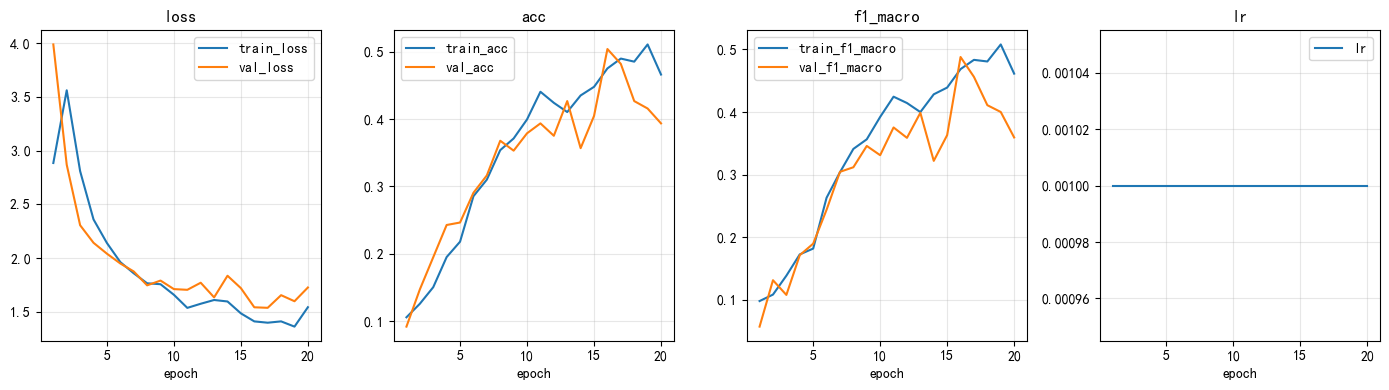

In [29]:
import gc
import sys
from pathlib import Path


gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from base import TorchTrainer, ReduceLROnPlateau


model = CNN(activation=F.selu).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

trainer = TorchTrainer(
    model=model,
    criterion=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_step="plateau",
    monitor="val_loss",
    mode="min",
    patience=5,
    device=device,
    amp=True,
    checkpoint_dir="./checkpoints/cnn_10monkeys"
)

trainer.fit(train_loader, val_loader, epochs=20)
trainer.plot_history()

## 训练、验证与资源清理

最后一段把模型放到 CPU 或 GPU 上训练，并调用项目里的 `TorchTrainer` 统一管理训练过程。训练前清理显存，在 notebook 里反复运行模型时很实用。


## 学习检查清单

完成本 notebook 后，可以尝试回答：
- `ImageFolder` 如何根据目录自动生成标签？
- 为什么训练集需要随机打乱，而验证集通常不打乱？
- 卷积层、池化层、全连接层分别承担什么角色？
- 如果验证准确率长期不上升，应该优先检查数据、模型还是训练参数？
